Found 4395 images belonging to 5 classes.
Found 775 images belonging to 5 classes.
Epoch 1/20
69/69 [==============================] - 44s 549ms/step - loss: 2.7738 - accuracy: 0.2778 - auc: 0.5779 - precision: 0.3318 - val_loss: 2.2869 - val_accuracy: 0.4284 - val_auc: 0.7465 - val_precision: 0.9000 - lr: 0.0010
Epoch 2/20
69/69 [==============================] - 41s 598ms/step - loss: 2.2764 - accuracy: 0.3927 - auc: 0.7127 - precision: 0.6894 - val_loss: 2.1633 - val_accuracy: 0.4748 - val_auc: 0.7679 - val_precision: 0.8222 - lr: 0.0010
Epoch 3/20
69/69 [==============================] - 46s 670ms/step - loss: 2.0783 - accuracy: 0.4783 - auc: 0.7849 - precision: 0.7476 - val_loss: 2.0462 - val_accuracy: 0.4735 - val_auc: 0.7786 - val_precision: 0.7576 - lr: 0.0010
Epoch 4/20
69/69 [==============================] - 45s 654ms/step - loss: 1.9293 - accuracy: 0.5354 - auc: 0.8271 - precision: 0.7610 - val_loss: 1.9632 - val_accuracy: 0.4671 - val_auc: 0.7920 - val_precision: 0.8155 - 

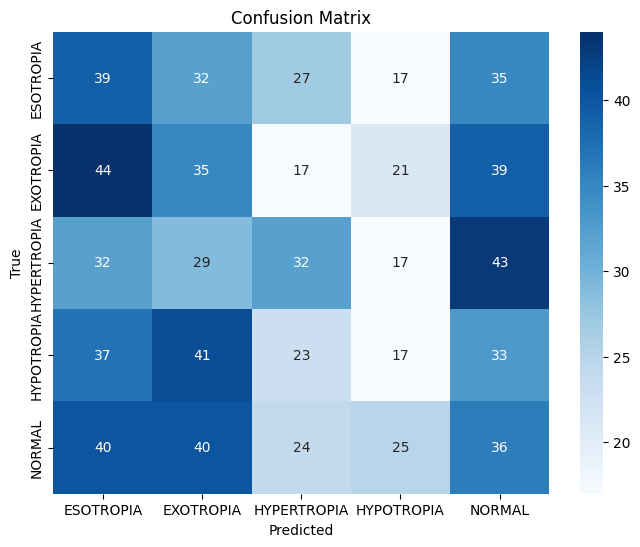

Model training and optimization complete.


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import Callback, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Define dataset path & parameters
data_dir = "E:/Projects/Strabismus/Denoised"
img_height, img_width = 224, 224
batch_size = 64
num_classes = 5  

# Data augmentation & preprocessing
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
    validation_split=0.15,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# Load & modify VGG19 model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  

# Define custom model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 15:
        return lr * 0.5
    else:
        return lr * 0.1

callback_lr = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Use AdamW Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile model
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision')])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[callback_lr, reduce_lr, early_stopping]
)

# Fine-tune by unfreezing some layers
for layer in base_model.layers[:10]:  
    layer.trainable = False
for layer in base_model.layers[10:]:  
    layer.trainable = True

# Recompile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Continue training with fine-tuning
model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[callback_lr, reduce_lr, early_stopping]
)

# Function to plot confusion matrix
def plot_confusion_matrix(model, generator):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=generator.class_indices.keys(), yticklabels=generator.class_indices.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot Confusion Matrix
plot_confusion_matrix(model, val_generator)

print("Model training and optimization complete.")


In [2]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_value_table(model, generator):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    
    # Compute classification report
    report = classification_report(y_true, y_pred, target_names=generator.class_indices.keys(), output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    
    # Print the table
    print(df_report)
    
    return df_report

# Generate and display value table
df_metrics = plot_value_table(model, val_generator)


NameError: name 'model' is not defined